Estrazione dataset solubilità

In [78]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset 
import sklearn
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
dataset=pd.read_csv('curated-solubility-dataset.csv')
scaler = StandardScaler()

Take just the columns where numeric data is present for X, y is the 10-power of the solubility column

In [79]:
numeric_cols = dataset.select_dtypes(include=np.number).columns
X = dataset[numeric_cols].drop(columns=['Solubility'])
y = dataset['Solubility']
#y=10**(y)   DON'T DO THIS, NNs WORK BETTER WITH non-skewed data.


Perform standardscaling, dataset split

In [98]:
X_std = scaler.fit_transform(X)
y_std = scaler.fit_transform(y.values.reshape(-1, 1)).flatten()
X_train, X_test, y_train, y_test = train_test_split(X_std, y_std, test_size=0.25, random_state=42)

Option 2: FFNN

In [105]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view([-1, 1])
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view([-1, 1])

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=16, shuffle=False)

# Architecture
network = nn.Sequential(
    nn.Linear(X_train.shape[1], 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)


epochs_number = 100
history_train_mse = []
history_test_mse = []

patience = 15
counter = 0

for epoch in range(epochs_number):
    network.train() 
    train_epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out = network(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        train_epoch_loss += loss.item() * len(y_batch)
    
    avg_train_mse = train_epoch_loss / len(X_train_tensor)
    history_train_mse.append(avg_train_mse)

    network.eval()
    test_epoch_loss = 0.0
    with torch.no_grad(): 
        for X_batch_t, y_batch_t in test_loader:
            out_t = network(X_batch_t)
            loss_t = criterion(out_t, y_batch_t)
            test_epoch_loss += loss_t.item() * len(y_batch_t)
    
    avg_test_mse = test_epoch_loss / len(X_test_tensor)
    history_test_mse.append(avg_test_mse)
    print(f"Epoch {epoch+1}/{epochs_number}, Train MSE: {avg_train_mse:.4f}, Test MSE: {avg_test_mse:.4f}", end="\r")
    best_test_mse = float('inf')
    

    # Dentro il loop for epoch...
    if avg_test_mse < best_test_mse:
        best_test_mse = avg_test_mse
        torch.save(network.state_dict(), 'best_model.pth') # Salva il top
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping alla epoca {epoch}")
        break
    

network.eval()
with torch.no_grad():
    y_pred_NN_scaled = network(X_test_tensor).numpy().flatten()

Evaluate the neural network

MSE:  0.2120438180497143
R2: 0.7822535313446997


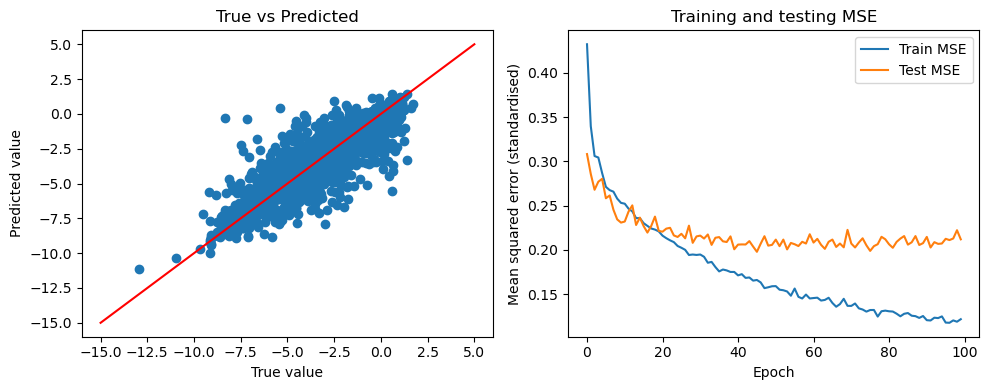

In [106]:

print("MSE: ", mean_squared_error(y_test, y_pred_NN_scaled))
print("R2:", r2_score(y_test, y_pred_NN_scaled))
with torch.no_grad():
    # Un-standardise: network learned in normalised space, plot in original units.
    y_pred_NN_original = scaler.inverse_transform(network(X_test_tensor).detach().numpy().flatten().reshape(-1, 1)).flatten()
    y_test_original = scaler.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(y_test_original, y_pred_NN_original, 'o')
ax[0].plot([-15, 5], [-15, 5], 'r-')
ax[0].set_xlabel('True value')
ax[0].set_ylabel('Predicted value')
ax[0].set_title('True vs Predicted')

ax[1].plot(history_train_mse)
ax[1].set_title('Training and testing MSE')
ax[1].set_ylabel('Mean squared error (standardised)')
ax[1].set_xlabel('Epoch')

ax[1].plot(history_test_mse)
ax[1].legend(['Train MSE', 'Test MSE'])


plt.tight_layout()
plt.show()